<a href="https://colab.research.google.com/github/geoshit888/GEOL0069-Landslide-Detection/blob/main/Hualien_Landslide_Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Landslide Detection in Taroko, Hualien, Taiwan using Sentinel-2

This notebook detects **candidate landslide areas** in Hualien / Taroko, Taiwan for **2022, 2023, 2024 and 2025** using an **unsupervised machine-learning workflow**.

This notebook uses Sentinel-2 Level-2A surface reflectance, SCL cloud/shadow masking, NDVI/NBR/NDMI/NDWI/BSI, year-to-year change indices, SRTM slope/elevation, and unsupervised K-means clustering in Google Earth Engine.

> Important: because this is unsupervised, the result should be described as **candidate landslide areas**


## 1. Install and import packages

In [1]:
!pip -q install geemap earthengine-api pandas matplotlib

import os
import time
from pathlib import Path

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print('Packages imported.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 41.4 MB/s eta 0:00:00
Packages imported.


## 2. Authenticate Google Earth Engine and mount Google Drive

In [66]:
try:
    ee.Initialize(project='my-ai-project-490112')
    print('Earth Engine already initialized.')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='my-ai-project-490112')
    print('Earth Engine initialized.')

from google.colab import drive
drive.mount('/content/drive')

Earth Engine already initialized.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Project settings



In [67]:
PROJECT_DIR = Path('/content/drive/MyDrive/hualien_landslide_unsupervised')
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

MAP_DIR = PROJECT_DIR / 'maps'
CSV_DIR = PROJECT_DIR / 'csv'
MAP_DIR.mkdir(exist_ok=True)
CSV_DIR.mkdir(exist_ok=True)

ALL_YEARS = [2021, 2022, 2023, 2024, 2025]
TARGET_YEARS = [2022, 2023, 2024, 2025]

SCALE = 20
CLOUD_FILTER = 70
N_CLUSTERS = 8
TRAINING_POINTS_PER_YEAR = 4000
RANDOM_SEED = 42

EXPORT_GEO_TIFFS_TO_DRIVE = False
DRIVE_EXPORT_FOLDER = 'hualien_landslide_unsupervised_exports'

# Hualien / Taroko AOI. Coordinates are [lon, lat].
AOI = ee.Geometry.Rectangle([121.32, 23.86, 121.75, 24.32])

# For 2024, start after the 2 April earthquake to emphasize post-event landslides.
YEAR_WINDOWS = {
    2021: ('2021-01-01', '2021-12-31'),
    2022: ('2022-01-01', '2022-12-31'),
    2023: ('2023-01-01', '2023-12-31'),
    2024: ('2024-04-10', '2024-12-31'),
    2025: ('2025-01-01', '2025-12-31'),
}

print('Project folder:', PROJECT_DIR)
print('AOI ready.')

Project folder: /content/drive/MyDrive/hualien_landslide_unsupervised
AOI ready.


## 4. Build Sentinel-2 annual composites

This fetches Sentinel-2 Level-2A Surface Reflectance, masks cloud/shadow using the SCL band, scales reflectance, and adds landslide-relevant indices. Landslide scars often show vegetation loss, lower NDVI/NBR, higher BSI, and occur on slopes.


In [69]:
S2_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
INDEX_BANDS = ['NDVI', 'NBR', 'NDMI', 'NDWI', 'BSI']
DELTA_BANDS = ['dNDVI', 'dNBR', 'dBSI']
TOPO_BANDS = ['elevation', 'slope']
FEATURE_BANDS = S2_BANDS + INDEX_BANDS + DELTA_BANDS + TOPO_BANDS

def get_s2_collection(year):
    start, end = YEAR_WINDOWS[year]
    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(AOI)
            .filterDate(start, end)
            .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

def mask_s2_scl_and_scale(img):
    img = ee.Image(img)
    scl = img.select('SCL')
    valid = (scl.neq(0)
             .And(scl.neq(1))
             .And(scl.neq(2))
             .And(scl.neq(3))
             .And(scl.neq(8))
             .And(scl.neq(9))
             .And(scl.neq(10))
             .And(scl.neq(11)))
    scaled = img.select(S2_BANDS).divide(10000).toFloat()
    return scaled.updateMask(valid).copyProperties(img, ['system:time_start'])

def add_indices(img):
    img = ee.Image(img)
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    nbr = img.normalizedDifference(['B8', 'B12']).rename('NBR')
    ndmi = img.normalizedDifference(['B8', 'B11']).rename('NDMI')
    ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')
    blue = img.select('B2')
    red = img.select('B4')
    nir = img.select('B8')
    swir1 = img.select('B11')
    bsi = (swir1.add(red).subtract(nir.add(blue))
           .divide(swir1.add(red).add(nir).add(blue))
           .rename('BSI'))
    return img.addBands([ndvi, nbr, ndmi, ndwi, bsi])

def annual_composite(year):
    col = get_s2_collection(year)
    count = col.size().getInfo()
    print(f'{year}: raw Sentinel-2 images = {count}')
    if count == 0:
        raise ValueError(f'No Sentinel-2 images found for {year}. Try changing YEAR_WINDOWS or AOI.')
    comp = col.map(mask_s2_scl_and_scale).median().clip(AOI)
    return add_indices(comp).set({'year': year})

dem = ee.Image('USGS/SRTMGL1_003').select('elevation').rename('elevation').clip(AOI)
slope = ee.Terrain.slope(dem).rename('slope').clip(AOI)
topo = dem.addBands(slope)

composites = {}
for year in ALL_YEARS:
    composites[year] = annual_composite(year)

print('Annual composites ready.')

2021: raw Sentinel-2 images = 99
2022: raw Sentinel-2 images = 66
2023: raw Sentinel-2 images = 66
2024: raw Sentinel-2 images = 63
2025: raw Sentinel-2 images = 86
Annual composites ready.


## 5. Build feature images with year-to-year change

In [70]:
feature_images = {}

for year in TARGET_YEARS:
    current = composites[year]
    previous = composites[year - 1]
    dndvi = current.select('NDVI').subtract(previous.select('NDVI')).rename('dNDVI')
    dnbr = current.select('NBR').subtract(previous.select('NBR')).rename('dNBR')
    dbsi = current.select('BSI').subtract(previous.select('BSI')).rename('dBSI')
    feature_images[year] = (current.select(S2_BANDS + INDEX_BANDS)
                            .addBands([dndvi, dnbr, dbsi])
                            .addBands(topo)
                            .select(FEATURE_BANDS)
                            .clip(AOI)
                            .toFloat())

print('Feature images ready:', list(feature_images.keys()))

Feature images ready: [2022, 2023, 2024, 2025]


## 6. Quick visual check of annual true-colour composites

In [71]:
# Calculate AOI area in km²

aoi_area_m2 = AOI.area(maxError=1).getInfo()
aoi_area_km2 = aoi_area_m2 / 1e6

print(f"AOI area = {aoi_area_km2:.2f} km²")

AOI area = 2232.66 km²


In [ ]:
Map = geemap.Map(center=[24.09, 121.53], zoom=10)
Map.addLayer(AOI, {}, 'AOI')
rgb_vis = {'bands': ['B4', 'B3', 'B2'], 'min': 0.02, 'max': 0.25, 'gamma': 1.2}
for year in TARGET_YEARS:
    Map.addLayer(composites[year], rgb_vis, f'{year} RGB', shown=(year==2024))
Map

## 7. Train an unsupervised K-means model

This samples pixels from all target years and trains a K-means clusterer. No labels are used.


In [73]:
def sample_feature_image(year):
    img = feature_images[year]
    sample = img.sample(region=AOI, scale=SCALE, numPixels=TRAINING_POINTS_PER_YEAR,
                        seed=RANDOM_SEED + year, geometries=False, tileScale=4)
    return sample.map(lambda f: f.set('sample_year', year))

samples = ee.FeatureCollection([])
for year in TARGET_YEARS:
    samples = samples.merge(sample_feature_image(year))

print('Sampling pixels for unsupervised training...')
print('Total sample count:', samples.size().getInfo())

clusterer = ee.Clusterer.wekaKMeans(N_CLUSTERS).train(features=samples, inputProperties=FEATURE_BANDS)
cluster_images = {year: feature_images[year].cluster(clusterer).rename('cluster').clip(AOI) for year in TARGET_YEARS}
print('K-means clusterer trained.')

Sampling pixels for unsupervised training...


Total sample count: 15984
K-means clusterer trained.


## 8. Automatically identify landslide-like clusters

A landslide-like cluster should tend to have high BSI, low NDVI, negative dNDVI/dNBR, positive dBSI, and moderate to steep slope.


In [74]:
def cluster_summary_for_year(year):
    img = feature_images[year].addBands(cluster_images[year])
    sample = img.sample(
        region=AOI,
        scale=SCALE,
        numPixels=3000,
        seed=RANDOM_SEED + 100 + year,
        geometries=False,
        tileScale=4
    )
    data = sample.getInfo()['features']
    return pd.DataFrame([f['properties'] for f in data])

summary_tables = []
for year in TARGET_YEARS:
    df = cluster_summary_for_year(year)
    df['year'] = year
    summary_tables.append(df)
cluster_sample_df = pd.concat(summary_tables, ignore_index=True)

summary = (cluster_sample_df
           .groupby('cluster')[['NDVI', 'NBR', 'NDMI', 'BSI', 'dNDVI', 'dNBR', 'dBSI', 'slope', 'elevation']]
           .mean().reset_index())
summary['landslide_score'] = (summary['BSI'] * 2.0 + (-summary['NDVI']) * 1.5 + (-summary['NBR']) * 0.8
                              + (-summary['dNDVI']) * 2.0 + (-summary['dNBR']) * 1.5
                              + summary['dBSI'] * 1.5 + (summary['slope'] / 45.0) * 0.8)
summary = summary.sort_values('landslide_score', ascending=False)
display(summary)

TOP_N_LANDSLIDE_CLUSTERS = 1
landslide_cluster_ids = summary.head(TOP_N_LANDSLIDE_CLUSTERS)['cluster'].astype(int).tolist()
print('Automatically selected landslide-like cluster IDs:', landslide_cluster_ids)

,cluster,NDVI,NBR,NDMI,BSI,dNDVI,dNBR,dBSI,slope,elevation,landslide_score
2,2,0.318407,0.167730,0.007709,0.011027,-0.084390,-0.048012,0.026063,42.091406,1688.514563,0.438442
6,6,-0.058400,0.058441,-0.014173,-0.111617,-0.000070,-0.031355,0.015499,0.149606,1.736219,-0.109307
7,7,0.251396,0.135922,0.008794,0.015377,-0.030630,-0.019076,0.012704,4.820761,94.315978,-0.260446
5,5,0.794635,0.541659,0.242515,-0.210718,-0.004985,-0.009304,0.009147,39.788823,1365.654432,-1.301715
3,3,0.805111,0.598115,0.311746,-0.272493,0.002408,0.001296,-0.002213,29.360748,2481.167473,-1.719255
0,0,0.859560,0.629528,0.324201,-0.296917,0.015066,0.015282,-0.014799,38.064087,902.240226,-1.785356
1,1,0.850905,0.639156,0.335023,-0.303283,0.015098,0.016837,-0.018004,30.894128,1831.184000,-1.927477
4,4,0.796225,0.557429,0.283276,-0.245920,0.019964,0.017650,-0.014947,10.320411,262.669643,-2.037470


Automatically selected landslide-like cluster IDs: [2]


## 9. Create yearly landslide candidate masks

Extra physical filters reduce false positives from riverbeds, roads and flat bare ground. Adjust thresholds after visual checking.


In [75]:
MIN_SLOPE = 12
MAX_NDVI = 0.65
MIN_BSI = -0.05
MAX_DNDVI = 0.05
MAX_DNBR = 0.05
MIN_CONNECTED_PIXELS = 5

def make_landslide_mask(year):
    cluster = cluster_images[year]
    img = feature_images[year]
    cluster_mask = cluster.remap(landslide_cluster_ids, [1] * len(landslide_cluster_ids), 0).rename('cluster_landslide')
    physical_mask = (img.select('slope').gte(MIN_SLOPE)
                     .And(img.select('NDVI').lte(MAX_NDVI))
                     .And(img.select('BSI').gte(MIN_BSI))
                     .And(img.select('dNDVI').lte(MAX_DNDVI))
                     .And(img.select('dNBR').lte(MAX_DNBR)))
    mask = cluster_mask.eq(1).And(physical_mask).rename('landslide_candidate')
    connected = mask.selfMask().connectedPixelCount(50, True)
    mask = mask.updateMask(connected.gte(MIN_CONNECTED_PIXELS)).unmask(0).rename('landslide_candidate')
    return mask.toByte().clip(AOI)

landslide_masks = {year: make_landslide_mask(year) for year in TARGET_YEARS}
print('Yearly landslide candidate masks ready.')

Yearly landslide candidate masks ready.


## 10. Display yearly landslide maps

In [ ]:
Map = geemap.Map(center=[24.09, 121.53], zoom=10)
Map.addLayer(AOI, {}, 'AOI')
mask_vis = {'min': 0, 'max': 1, 'palette': ['00000000', 'ff0000']}
for year in TARGET_YEARS:
    Map.addLayer(composites[year], rgb_vis, f'{year} RGB', shown=(year==2024))
    Map.addLayer(landslide_masks[year].selfMask(), mask_vis, f'{year} candidate landslides', shown=(year==2024))
Map

Processing 2022...


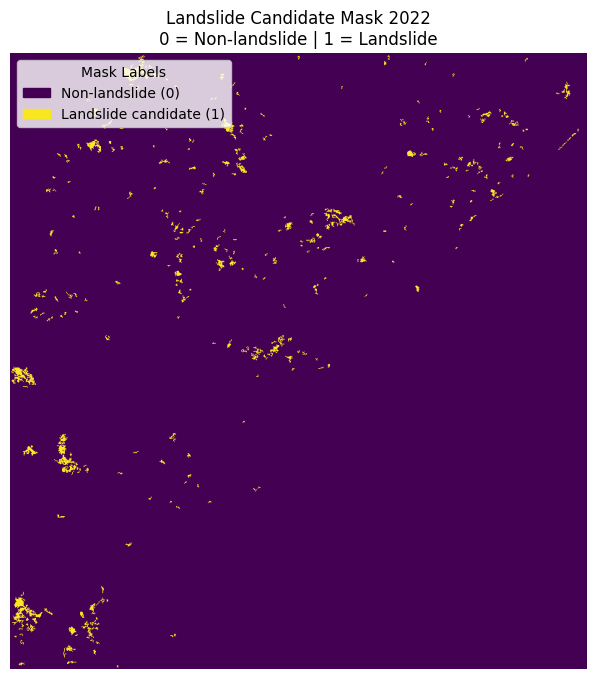

Processing 2023...


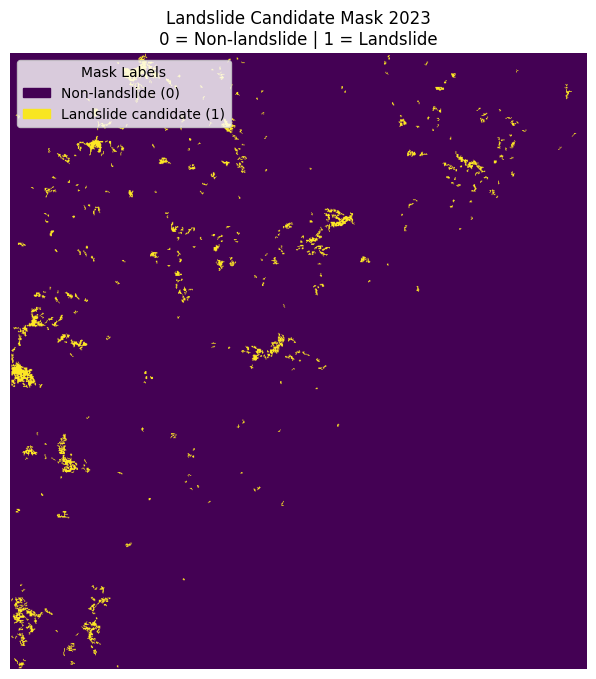

Processing 2024...


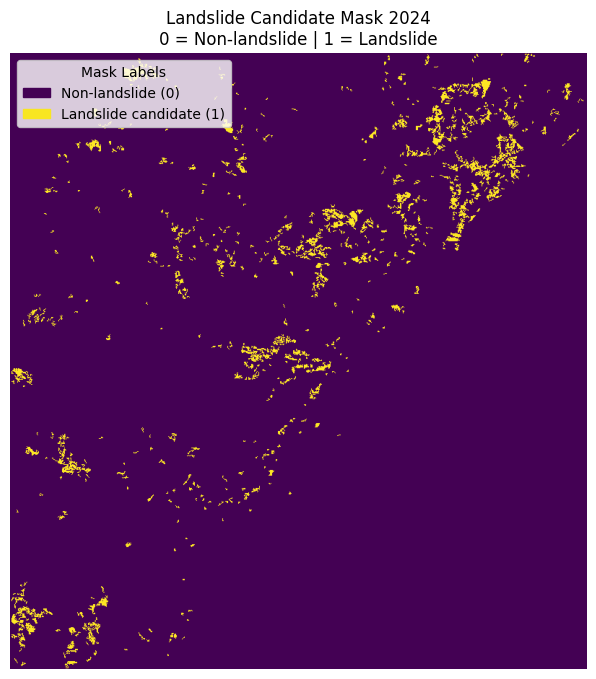

Processing 2025...


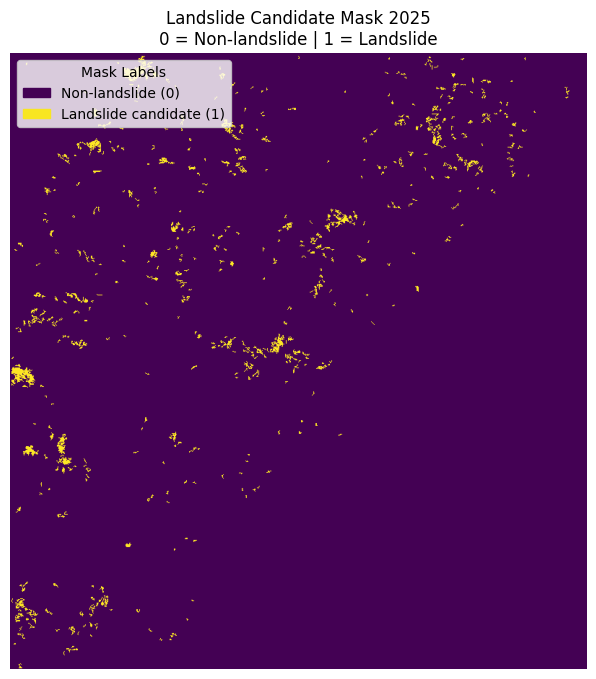

In [77]:
# Display yearly landslide masks for all years
# 0 = non-landslide
# 1 = landslide candidate

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

PLOT_SCALE = 60  # increase if memory errors occur

for year in TARGET_YEARS:
    print(f'Processing {year}...')
    mask_array = geemap.ee_to_numpy(
        landslide_masks[year]
        .unmask(0)
        .toByte(),
        region=AOI,
        scale=PLOT_SCALE)
    # Remove extra band dimension if present
    if mask_array.ndim == 3:
        mask_array = mask_array[:, :, 0]

    # Ensure only 0 and 1
    mask_array = np.where(mask_array == 1, 1, 0)

    # Plot
    plt.figure(figsize=(8, 8))
    plt.imshow(
        mask_array,
        cmap='viridis',
        vmin=0,
        vmax=1)
    plt.title(
        f'Landslide Candidate Mask {year}\n'
        '0 = Non-landslide | 1 = Landslide')
    plt.axis('off')

    # Legend
    patches = [
        Rectangle((0, 0), 1, 1, color=plt.cm.viridis(0.0)),
        Rectangle((0, 0), 1, 1, color=plt.cm.viridis(0.99)),]
    labels = [
        'Non-landslide (0)',
        'Landslide candidate (1)']
    plt.legend(
        patches,
        labels,
        loc='upper left',
        title='Mask Labels')

    plt.show()

## 12. Calculate landslide candidate area for each year

In [78]:
def calculate_area_km2(mask):
    area_img = mask.eq(1).multiply(ee.Image.pixelArea()).rename('area_m2')
    stats = area_img.reduceRegion(reducer=ee.Reducer.sum(), geometry=AOI, scale=SCALE,
                                  maxPixels=1e13, tileScale=4)
    area_m2 = ee.Number(stats.get('area_m2')).getInfo()
    if area_m2 is None:
        area_m2 = 0
    return area_m2 / 1e6

area_rows = []
for year in TARGET_YEARS:
    area_km2 = calculate_area_km2(landslide_masks[year])
    area_rows.append({'year': year, 'candidate_landslide_area_km2': area_km2})
    print(year, f'{area_km2:.3f} km²')

area_df = pd.DataFrame(area_rows)
display(area_df)
csv_path = CSV_DIR / 'hualien_unsupervised_landslide_area_2022_2025.csv'
area_df.to_csv(csv_path, index=False)
print('Saved:', csv_path)

2022 27.949 km²
2023 37.856 km²
2024 63.120 km²
2025 41.309 km²


,year,candidate_landslide_area_km2
0,2022,27.949303
1,2023,37.855979
2,2024,63.119781
3,2025,41.308738


Saved: /content/drive/MyDrive/hualien_landslide_unsupervised/csv/hualien_unsupervised_landslide_area_2022_2025.csv


## 13. Plot annual landslide candidate area

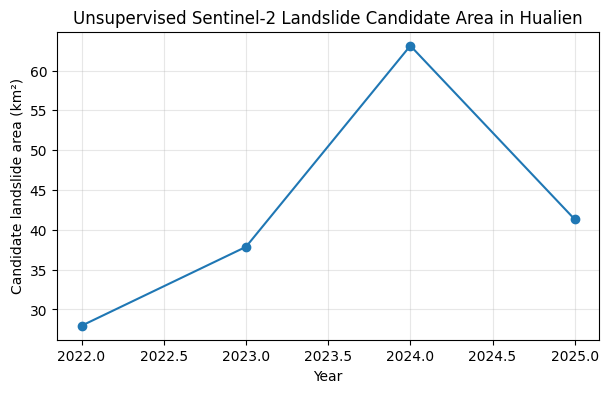

In [79]:
plt.figure(figsize=(7, 4))
plt.plot(area_df['year'], area_df['candidate_landslide_area_km2'], marker='o')
plt.xlabel('Year')
plt.ylabel('Candidate landslide area (km²)')
plt.title('Unsupervised Sentinel-2 Landslide Candidate Area in Hualien')
plt.grid(True, alpha=0.3)
plt.show()

## 14. Year-to-year new candidate landslide change

2022 new candidate area = 27.949 km²
2023 new candidate area = 19.767 km²
2024 new candidate area = 41.742 km²
2025 new candidate area = 20.292 km²


,year,new_candidate_landslide_area_km2
0,2022,27.949303
1,2023,19.767443
2,2024,41.742197
3,2025,20.291680


Saved: /content/drive/MyDrive/hualien_landslide_unsupervised/csv/hualien_unsupervised_new_landslide_area_2022_2025.csv


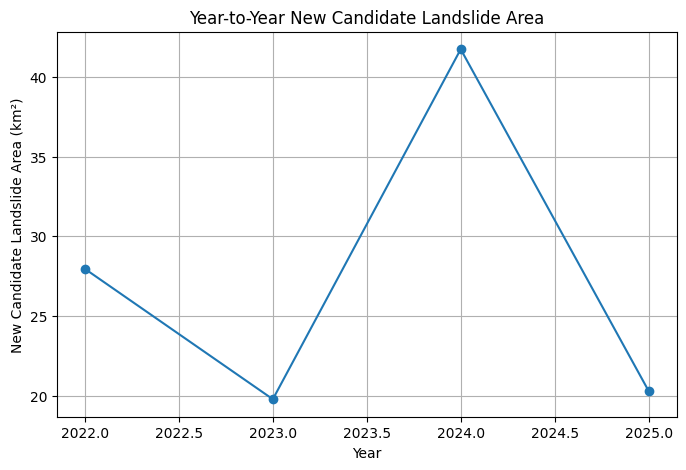

In [80]:
## 14. Year-to-year new candidate landslide change

new_landslide_masks = {}

for i, year in enumerate(TARGET_YEARS):
    if i == 0:
        new_landslide_masks[year] = landslide_masks[year]
    else:
        prev_year = TARGET_YEARS[i - 1]

        new_landslide_masks[year] = (
            landslide_masks[year]
            .eq(1)
            .And(landslide_masks[prev_year].neq(1))
            .rename('new_candidate')
            .toByte())

# Calculate yearly new landslide area
change_rows = []

for year in TARGET_YEARS:
    area_km2 = calculate_area_km2(
        new_landslide_masks[year])
    change_rows.append({
        'year': year,
        'new_candidate_landslide_area_km2': area_km2 })
    print(
        year,
        f'new candidate area = {area_km2:.3f} km²' )

# Create dataframe
change_df = pd.DataFrame(change_rows)
display(change_df)

# Save CSV
change_csv_path = (CSV_DIR /'hualien_unsupervised_new_landslide_area_2022_2025.csv')
change_df.to_csv(
    change_csv_path,
    index=False)
print('Saved:', change_csv_path)

plt.figure(figsize=(8, 5))
plt.plot(
    change_df['year'],
    change_df['new_candidate_landslide_area_km2'],
    marker='o')
plt.xlabel('Year')
plt.ylabel('New Candidate Landslide Area (km²)')
plt.title('Year-to-Year New Candidate Landslide Area')
plt.grid(True)
plt.show()

## 15. Download data

In [ ]:
# Save CSV + RGB maps + landslide candidate maps + new landslide maps into Google Drive folder


from pathlib import Path
from IPython.display import Image, display
import requests

# Main output folder in Google Drive
OUTPUT_ROOT = Path("/content/drive/MyDrive/Hualien_Landslide_Results")

CSV_OUTPUT_DIR = OUTPUT_ROOT / "csv"
RGB_OUTPUT_DIR = OUTPUT_ROOT / "rgb"
LANDSLIDE_OUTPUT_DIR = OUTPUT_ROOT / "landslide_candidates"
NEW_LANDSLIDE_OUTPUT_DIR = OUTPUT_ROOT / "new_landslide_candidates"

for folder in [
    OUTPUT_ROOT,
    CSV_OUTPUT_DIR,
    RGB_OUTPUT_DIR,
    LANDSLIDE_OUTPUT_DIR,
    NEW_LANDSLIDE_OUTPUT_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Created output folders in Google Drive:")
print(OUTPUT_ROOT)


# Save CSV files

area_csv_path = CSV_OUTPUT_DIR / f"{AOI_NAME}_candidate_landslide_area.csv"
area_df.to_csv(area_csv_path, index=False)
print("Saved:", area_csv_path)

change_csv_path = CSV_OUTPUT_DIR / f"{AOI_NAME}_new_candidate_landslide_area.csv"
change_df.to_csv(change_csv_path, index=False)
print("Saved:", change_csv_path)


# Helper function to save Earth Engine quicklook PNG

def save_ee_png(image, region, output_path, dimensions=900):
    url = image.getThumbURL({
        "region": region,
        "dimensions": dimensions,
        "format": "png"
    })
    r = requests.get(url)
    r.raise_for_status()
    output_path.write_bytes(r.content)
    display(Image(data=r.content))
    print("Saved:", output_path)
for year in TARGET_YEARS:
    print(f"\nProcessing {year}...")

# RGB quicklook
    rgb = composites[year].select(["B4", "B3", "B2"]).visualize(
        min=0.02,
        max=0.35,
        gamma=1.2
    ).clip(AOI)
    rgb_path = RGB_OUTPUT_DIR / f"{AOI_NAME}_rgb_{year}.png"
    try:
        save_ee_png(rgb, AOI, rgb_path)
    except Exception as e:
        print(f"Could not save RGB PNG for {year}: {e}")

# Landslide candidate map: RGB + red landslide overlay
    landslide_overlay = landslide_masks[year].selfMask().visualize(
        palette=["ff0000"],
        opacity=0.75)
    landslide_quicklook = rgb.blend(landslide_overlay).clip(AOI)
    landslide_path = LANDSLIDE_OUTPUT_DIR / f"{AOI_NAME}_landslide_candidates_{year}.png"
    try:
        save_ee_png(landslide_quicklook, AOI, landslide_path)
    except Exception as e:
        print(f"Could not save landslide candidate PNG for {year}: {e}")

# New landslide candidate map: RGB + yellow new landslide overlay
    new_landslide_overlay = new_landslide_masks[year].selfMask().visualize(
        palette=["ffff00"],
        opacity=0.85)
    new_landslide_quicklook = rgb.blend(new_landslide_overlay).clip(AOI)
    new_landslide_path = NEW_LANDSLIDE_OUTPUT_DIR / f"{AOI_NAME}_new_landslide_candidates_{year}.png"
    try:
        save_ee_png(new_landslide_quicklook, AOI, new_landslide_path)
    except Exception as e:
        print(f"Could not save new landslide candidate PNG for {year}: {e}")

print("\nAll available outputs saved to:")
print(OUTPUT_ROOT)